# Notebook 04 — Final Evaluation of the Winning Detectors

**This notebook:** the full report card for the two tournament winners
(both rule-based, per NB03's criterion): the **onset detector** (mean of
the five-feature onset bank, coverage + above-median-attention gates) and
the **top detector** (the incumbent construction, confirmed). Everything
here is out-of-sample: alerts come from the same walk-forward run the
tournament scored — nothing is re-fitted for this notebook.

Contents: per-year scorecards (both denominators) → lead-time
distributions → false-alarm anatomy → calibration → case studies
(including a missed episode) → the **trading-translation study** with its
own pre-stated criterion.

## Trading-translation criterion (pre-stated HERE, before any return is
computed)

The desk's framing: buy/sell value is a *secondary* claim — adopt it only
if it is clearly not noise. An alert class earns a trading claim only if
ALL hold:

1. **N ≥ 30** judged alerts (fewer is anecdote, not evidence);
2. the mean forward return over the existing **HOLD_DAYS = 20** horizon
   (the project's frozen holding period — no new constant) differs from
   the same-instrument unconditional baseline in the expected direction
   (onset ⇒ higher, top ⇒ lower);
3. the 90% instrument-cluster bootstrap CI of that difference **excludes
   zero**.

If any clause fails, the trading claim is REJECTED and recorded — the same
treatment the retired BUY/SELL engine received.

## Glossary — every term in plain English

(Very technical project, deliberately simple words. "Own history" always
means the SAME instrument's past — extreme always means *extreme for this
name*, never an absolute count.)

| Term | Plain English |
|---|---|
| mention share | of everything posted today, the fraction that talks about this name — immune to the whole platform having a busy or quiet day |
| percentile rank | where today sits inside this name's own last 365 days: 0 = quietest it has been, 1 = the most extreme it has been |
| **E1** attention extremity | how unusually LOUD the chatter is this week (7-day share, ranked vs its own year) — you cannot be euphoric quietly |
| **E2** sustained bullishness | how one-way POSITIVE the last 4 weeks lean — and it only counts if at least 75% of posting days leaned bullish (weeks of one-way mood, not one loud afternoon) |
| **E3** crowd influx | how fast the share of chatter has GROWN over 4 weeks — new people still arriving |
| **E5** / attention_convexity | attention growing FASTER than exponential (the log of the mention count curving upward) — the classic bubble signature, measured on the crowd, never on the chart |
| **E4** fade | the crowd is still at maximum size but the mood just rolled over — historically the LAST stage before a top, so it lets the alert fire slightly earlier |
| attention_accel | this week's crowd is bigger than this month's average — arriving fast |
| hype_ratio | this week's share vs the name's own NORMAL level (its 120-day median); 2× is the "the crowd has genuinely swollen" bar |
| bull_inflection | the mood TURNING up quickly (2-week change of the 2-week bullish lean) |
| influx_speed | E3 at double speed — share growth measured over 2 weeks |
| euphoria level | 100 × the average of the bank's percentile features — one 0-100 number per name per day |
| coverage gate (A0) | at least 100 scored posts in 28 days — below that, "extremes" are noise wearing a costume |
| hype gate (A1) | the week's share must be ≥ 2× the name's own normal — something must actually have gone euphoric first |
| walk-forward | each year's alert threshold is chosen using ONLY earlier years — the detector never peeks at the future it is graded on |
| episode | trough → boom → peak → bust, defined purely by PRICE — the answer key for grading, never an input |
| onset window | [trough, trough + 45d, capped at the peak] — the "you caught the start" zone |
| captured / hit | at least one alert landed inside the window |
| LATE | an onset alert during the rally but past its start — reported separately: neither a hit nor a false alarm |
| false alarm (FA) | an alert with no qualifying episode around it; FA/instr-yr = false alarms per instrument per year |
| detectable | enough post coverage existed to measure the crowd at all — the honest denominator (a top during a data desert is missed data, not a miss) |
| pending | too recent to judge (needs 45 days of future price) — pending is not false |
| AP (average precision) | rank all days by the detector's score: how concentrated are the TRUE euphoria days at the top of that ranking? baseline = the base rate; higher = better |
| AUROC | the probability that a randomly chosen euphoria day out-scores a randomly chosen ordinary day; 0.5 = coin flip |

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"

## Reproduce the winners' walk-forward alerts (the tournament's exact path)

In [2]:
from analytics.euphoria import build_all_series
from analytics.euphoria_phases import (build_day_frame, run_tournament_entry,
                                       walk_forward_scores, ONSET_WINDOW_DAYS)
from analytics.loaders import load, THEME_COUNTS, THEME_SENT, \
    TICKER_COUNTS, TICKER_SENT
from src.config import HOLD_DAYS

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)

FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]
from analytics.euphoria_phases import ONSET_BANK  # the LOCKED bank
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK
onset_frame = frame[frame.hype_raw >= 1].copy()
top_frame = frame[frame.hype_ok].copy()

def rules_onset(train, apply, feats):
    return apply[feats].mean(axis=1).values

def rules_top(train, apply, feats):
    score = apply[feats].mean(axis=1).values
    gate = (apply["e1"] >= 0.90) & (apply["e2"] > 0)
    return np.where(gate, score, 0.0)

ow = run_tournament_entry(onset_frame, episodes, ONSET_BANK, "y_onset",
                          "onset", rules_onset, FA_BUDGET)
tw = run_tournament_entry(top_frame, episodes, TOP_BANK, "y_top",
                          "top", rules_top, FA_BUDGET)
kind_by = {es.name: es.kind for es in series}
sym_by = {es.name: es.symbol for es in series}
print(f"{time.time()-t0:.0f}s | onset: {ow['captured']}/{ow['detectable']} "
      f"captured, {ow['late']} late, {ow['false_alarms']} FA | top: "
      f"{tw['captured']}/{tw['detectable']} captured, "
      f"{tw['false_alarms']} FA")

48s | onset: 29/125 captured, 21 late, 169 FA | top: 16/122 captured, 44 FA


## Per-year scorecards — both denominators, always

In [3]:
from analytics.euphoria_phases import (classify_onset_alerts,
                                       classify_top_alerts, _eps_arrays,
                                       _day_ints)

def captured_rows(entry, mode):
    """(name, peak, alert) for every captured episode + classified FA/LATE
    lists, resolved back to the catalog rows."""
    judge = (classify_onset_alerts if mode == "onset"
             else classify_top_alerts)
    caps, fas, lates = [], [], []
    for name, alerts in entry["alerts_by_name"].items():
        eps = episodes[episodes.name == name]
        res = judge(_day_ints(pd.DatetimeIndex(alerts)), _eps_arrays(eps))
        peak_ints = dict(zip(_day_ints(eps["peak"]), eps["peak"]))
        caps += [{"name": name, "peak": peak_ints[p]} for p in res["captured"]]
        fas += [{"name": name,
                 "date": pd.Timestamp(np.datetime64(int(a), "D"))}
                for a in res["fa"]]
        lates += [{"name": name,
                   "date": pd.Timestamp(np.datetime64(int(a), "D"))}
                  for a in res["late"]]
    return (pd.DataFrame(caps), pd.DataFrame(fas), pd.DataFrame(lates))

onset_caps, onset_fas, onset_lates = captured_rows(ow, "onset")
top_caps, top_fas, _ = captured_rows(tw, "top")

def yearly(entry, caps, mode):
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    rows = []
    for y in entry["test_years"]:
        det = episodes[(episodes.year == y) & episodes[det_col]]
        allp = episodes[episodes.year == y]
        c = 0 if caps.empty else (caps.peak.dt.year == y).sum()
        rows.append({"year": y, "all_episodes": len(allp),
                     "detectable": len(det), "captured": int(c),
                     "capture_rate_detectable":
                         round(c / len(det), 2) if len(det) else None})
    return pd.DataFrame(rows)

print("ONSET, per year:"); display(yearly(ow, onset_caps, "onset"))
print("TOP, per year:");   display(yearly(tw, top_caps, "top"))

ONSET, per year:


,year,all_episodes,detectable,captured,capture_rate_detectable
0,2018,10,5,0,0.00
1,2019,21,8,1,0.12
2,2020,50,24,5,0.21
3,2021,62,52,14,0.27
4,2022,47,24,9,0.38
5,2023,35,7,0,0.00
6,2024,44,0,0,NaN
7,2025,34,0,0,NaN
8,2026,22,5,0,0.00


TOP, per year:


,year,all_episodes,detectable,captured,capture_rate_detectable
0,2020,50,24,2,0.08
1,2021,62,58,13,0.22
2,2022,47,22,1,0.05
3,2023,35,5,0,0.00
4,2024,44,0,0,NaN
5,2025,34,0,0,NaN
6,2026,22,13,1,0.08


## Lead times — did we actually catch the START and the END?

Onset leads are read two ways: days after the trough (how early into the
run-up the flag came) and days before the peak (how much of the rally was
left). Top leads use the stated aim's clock (days before the peak, inside
[−30, +1]).

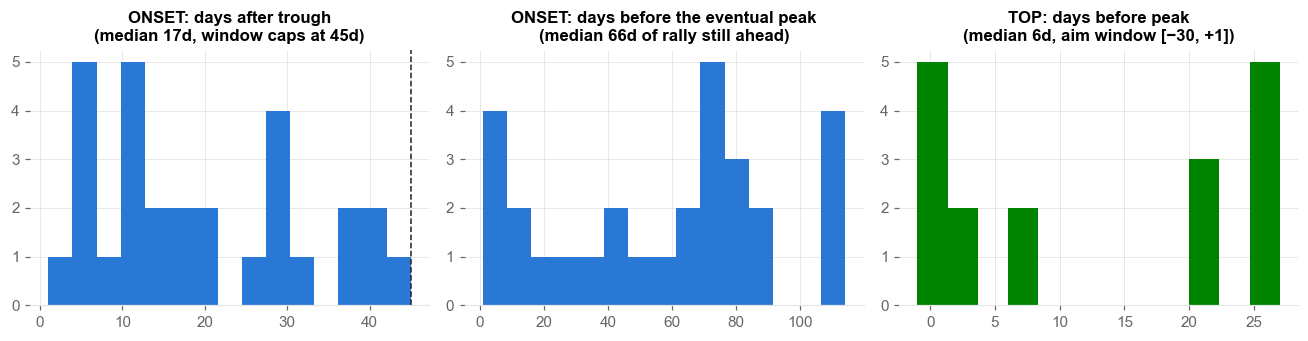

In [4]:
onset_leads = pd.DataFrame(ow["leads"])
top_leads = pd.DataFrame(tw["leads"])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].hist(onset_leads["after_trough"], bins=15, color=C1)
axes[0].axvline(ONSET_WINDOW_DAYS, color=INK, ls="--", lw=1)
axes[0].set_title(f"ONSET: days after trough\n(median "
                  f"{onset_leads['after_trough'].median():.0f}d, window "
                  f"caps at {ONSET_WINDOW_DAYS}d)")
axes[1].hist(onset_leads["before_peak"], bins=15, color=C1)
axes[1].set_title(f"ONSET: days before the eventual peak\n(median "
                  f"{onset_leads['before_peak'].median():.0f}d of rally "
                  "still ahead)")
axes[2].hist(top_leads["before_peak"], bins=12, color=C2)
axes[2].set_title(f"TOP: days before peak\n(median "
                  f"{top_leads['before_peak'].median():.0f}d, aim window "
                  "[−30, +1])")
for ax in axes:
    despine(ax)
fig.tight_layout()
plt.show()

## False-alarm anatomy — what fools the onset detector?

Each FA is placed relative to the nearest episode of its instrument:
**early** (a trough follows within 90d — the crowd moved before the price
basing was measurable), **post-peak** (inside 90d after a peak — the crowd
was still hot while price broke), or **isolated** (no episode within 90d
either side — attention flared, no qualifying rally ever came).

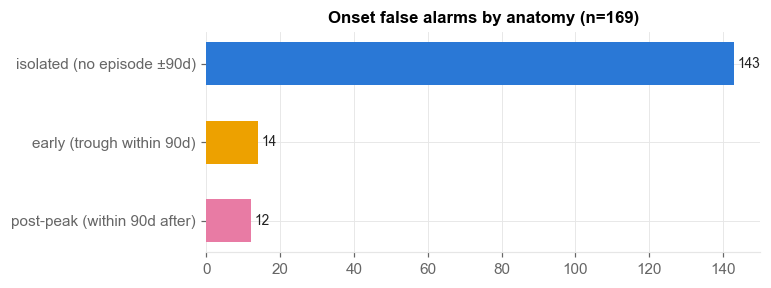

isolated (no episode ±90d)      143
early (trough within 90d)        14
post-peak (within 90d after)     12


In [5]:
def fa_anatomy(fas):
    rows = []
    for r in fas.itertuples():
        eps = episodes[episodes.name == r.name]
        d_trough = ((eps.trough - r.date).dt.days)
        d_peak = ((r.date - eps.peak).dt.days)
        early = ((d_trough > 0) & (d_trough <= 90)).any()
        post = ((d_peak > 0) & (d_peak <= 90)).any()
        rows.append("early (trough within 90d)" if early
                    else "post-peak (within 90d after)" if post
                    else "isolated (no episode ±90d)")
    return pd.Series(rows).value_counts()

anatomy = fa_anatomy(onset_fas)
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(anatomy.index[::-1], anatomy.values[::-1], color=[C3, C4, C1],
        height=0.55)
for i, v in enumerate(anatomy.values[::-1]):
    ax.text(v + 1, i, str(v), va="center", fontsize=9, color=INK)
ax.set_title(f"Onset false alarms by anatomy (n={int(anatomy.sum())})")
despine(ax)
plt.show()
print(anatomy.to_string())

## Calibration — does a higher score mean a higher hit probability?

Pooled walk-forward test scores, bucketed into deciles; each bucket's
empirical P(onset window). Honesty rule from the existing evidence pack:
if the curve is not monotone, the figure says so on its face.

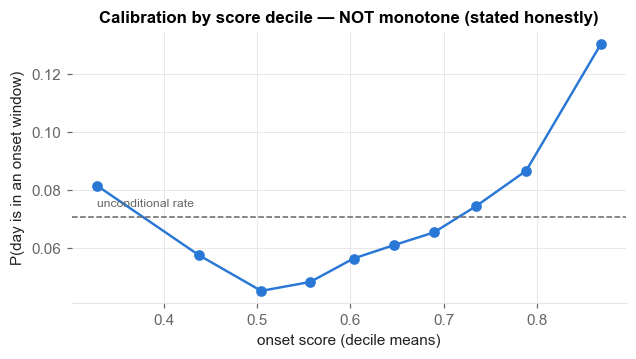

In [6]:
scored = walk_forward_scores(onset_frame, ONSET_BANK, "y_onset", rules_onset)
dec = pd.qcut(scored["score"], 10, labels=False, duplicates="drop")
calib = scored.groupby(dec).agg(p=("y_onset", "mean"),
                                n=("y_onset", "size"),
                                s=("score", "mean"))
mono = bool(calib["p"].is_monotonic_increasing)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(calib["s"], calib["p"], "o-", color=C1, lw=1.6)
ax.axhline(scored["y_onset"].mean(), color=MUTED, lw=1, ls="--")
ax.text(calib["s"].iloc[0], scored["y_onset"].mean() * 1.05,
        "unconditional rate", fontsize=8, color=MUTED)
ax.set_xlabel("onset score (decile means)")
ax.set_ylabel("P(day is in an onset window)")
ax.set_title("Calibration by score decile — "
             + ("monotone" if mono else "NOT monotone (stated honestly)"))
despine(ax)
plt.show()

## Case studies — captured, and (honesty) missed

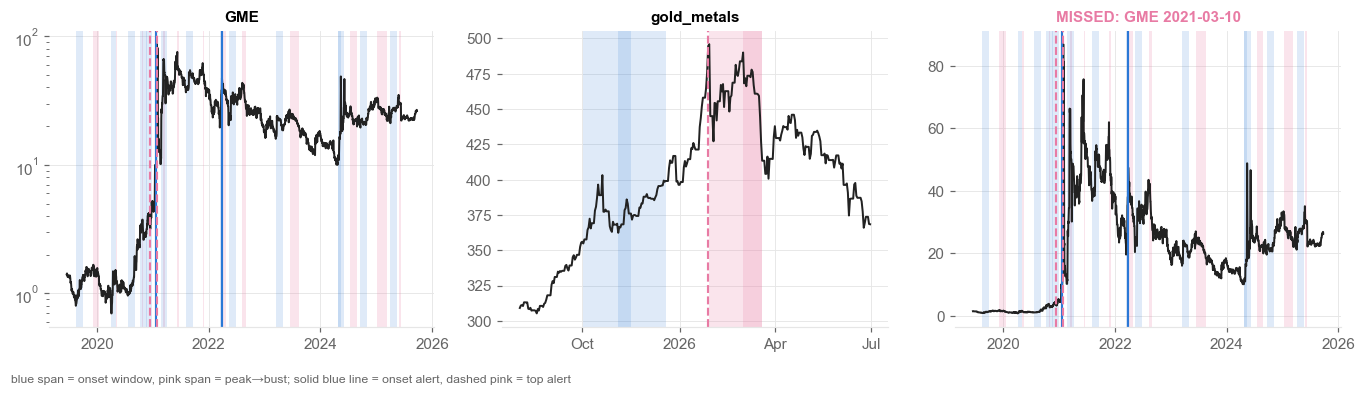

missed episode (largest detectable): GME peak 2021-03-10, boom +2307%


In [7]:
def case_panel(ax, name, log=False):
    sym = sym_by[name]
    px = pxmap[sym].dropna()
    eps = episodes[episodes.name == name]
    alerts_o = ow["alerts_by_name"].get(name, [])
    alerts_t = tw["alerts_by_name"].get(name, [])
    lo = eps.trough.min() - pd.Timedelta(days=60)
    hi = eps.peak.max() + pd.Timedelta(days=120)
    win = px.loc[lo:hi]
    ax.plot(win.index, win.values, color=INK, lw=1.3)
    for ep in eps.itertuples():
        ax.axvspan(ep.onset_lo, ep.onset_hi, color=C1, alpha=0.15, lw=0)
        if ep.bust_date is not None and not pd.isna(ep.bust_date):
            ax.axvspan(ep.peak, ep.bust_date, color=C3, alpha=0.2, lw=0)
    for a in alerts_o:
        if lo <= a <= hi:
            ax.axvline(a, color=C1, lw=1.4)
    for a in alerts_t:
        if lo <= a <= hi:
            ax.axvline(a, color=C3, lw=1.4, ls="--")
    if log:
        ax.set_yscale("log")
    loc = mdates.AutoDateLocator(minticks=3, maxticks=5)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax.set_title(name, fontsize=10)
    despine(ax)

# panels: GME (the archetype), gold 2026 (the recent theme call), and the
# LARGEST detectable episode the onset detector MISSED (data-chosen)
missed = episodes[episodes.onset_detectable].copy()
if not onset_caps.empty:
    got = set(zip(onset_caps.name, onset_caps.peak))
    missed = missed[~missed.apply(lambda r: (r["name"], r["peak"]) in got,
                                  axis=1)]
biggest_miss = missed.sort_values("boom_pct", ascending=False).iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
case_panel(axes[0], "GME", log=True)
case_panel(axes[1], "gold_metals")
case_panel(axes[2], biggest_miss["name"])
axes[2].set_title(f"MISSED: {biggest_miss['name']} "
                  f"{biggest_miss.peak.date()}", fontsize=10, color=C3)
fig.tight_layout()
fig.text(0.01, -0.04, "blue span = onset window, pink span = peak→bust; "
         "solid blue line = onset alert, dashed pink = top alert",
         fontsize=8, color=MUTED)
plt.show()
print(f"missed episode (largest detectable): {biggest_miss['name']} "
      f"peak {biggest_miss.peak.date()}, boom "
      f"+{100*biggest_miss.boom_pct:.0f}%")

## Hit rate by THEME (the official ETF list) and by single name

Per-instrument scorecards for both detectors. **Read with care:** most
individual denominators are tiny (a theme with 2 detectable episodes and
1 capture shows 50% — that is one event, not a rate), so these tables
are for seeing WHERE the detectors work, while the pooled rates above
remain the honest headline. Sorted by captures, then alerts.

In [8]:
def per_name_table(kind):
    rows = []
    for es in [s_ for s_ in series if s_.kind == kind]:
        name = es.name
        eps = episodes[episodes.name == name]
        o_det = int(eps.onset_detectable.sum())
        t_det = int(eps.top_detectable.sum())
        o_cap = 0 if onset_caps.empty else int((onset_caps.name == name).sum())
        t_cap = 0 if top_caps.empty else int((top_caps.name == name).sum())
        rows.append({
            "name": name, "symbol": es.symbol,
            "episodes": len(eps),
            "onset detectable": o_det, "onset captured": o_cap,
            "onset hit rate": round(o_cap / o_det, 2) if o_det else None,
            "top detectable": t_det, "top captured": t_cap,
            "top hit rate": round(t_cap / t_det, 2) if t_det else None,
            "onset alerts": len(ow["alerts_by_name"].get(name, [])),
            "top alerts": len(tw["alerts_by_name"].get(name, [])),
        })
    return (pd.DataFrame(rows)
            .sort_values(["onset captured", "top captured",
                          "onset alerts"], ascending=False)
            .reset_index(drop=True))

print("THEMES (all official anchor ETFs in the euphoria universe):")
display(per_name_table("theme"))
print("SINGLE NAMES (the data-chosen top-25):")
display(per_name_table("single"))

THEMES (all official anchor ETFs in the euphoria universe):


,name,symbol,episodes,onset detectable,onset captured,onset hit rate,top detectable,top captured,top hit rate,onset alerts,top alerts
0,uranium_nuclear,URA,15,7,5,0.71,9,1,0.11,5,2
1,meme_stocks,ARKK,15,9,4,0.44,9,1,0.11,9,5
2,short_squeeze,ARKK,15,9,3,0.33,9,2,0.22,9,3
3,semiconductors,SMH,7,6,2,0.33,6,0,0.00,3,2
4,cloud_saas,IGV,4,3,1,0.33,3,0,0.00,10,1
5,ai,IYW,2,1,1,1.00,1,0,0.00,8,3
6,biotech_pharma,XBI,5,4,1,0.25,4,0,0.00,7,0
7,china_geopolitics,KWEB,16,9,1,0.11,9,0,0.00,4,0
8,gold_metals,GLD,2,0,0,NaN,2,1,0.50,9,2
9,space,ITA,2,0,0,NaN,2,1,0.50,7,3


SINGLE NAMES (the data-chosen top-25):


,name,symbol,episodes,onset detectable,onset captured,onset hit rate,top detectable,top captured,top hit rate,onset alerts,top alerts
0,AMC,AMC,18,5,2,0.40,4,1,0.25,1,2
1,SNAP,SNAP,11,5,2,0.40,2,0,0.00,4,0
2,BABA,BABA,4,2,2,1.00,1,0,0.00,2,0
3,SPCE,SPCE,17,5,2,0.40,7,0,0.00,1,0
4,GME,GME,14,4,1,0.25,5,1,0.20,2,2
5,WKHS,WKHS,22,3,1,0.33,2,1,0.50,1,1
6,TSLA,TSLA,6,5,1,0.20,5,0,0.00,7,3
7,TLRY,TLRY,15,2,0,0.00,4,2,0.50,3,3
8,BBBY,BBBY,16,1,0,0.00,3,2,0.67,2,3
9,MVIS,MVIS,24,5,0,0.00,4,2,0.50,0,2


## Trading translation — judged by the criterion pre-stated at the top

In [9]:
def forward_return(name, date, days=HOLD_DAYS):
    px = pxmap[sym_by[name]].dropna()
    fut = px.loc[date:date + pd.Timedelta(days=days)]
    if len(fut) < 2:
        return np.nan
    return float(fut.iloc[-1] / fut.iloc[0] - 1)

def alert_returns(entry):
    rows = []
    for name, alerts in entry["alerts_by_name"].items():
        for a in alerts:
            r = forward_return(name, a)
            if not np.isnan(r):
                rows.append({"name": name, "date": a, "fwd": r})
    return pd.DataFrame(rows)

def baseline_returns(names):
    """Unconditional same-instrument baseline: HOLD_DAYS forward return
    of EVERY candidate day (the days a detector was allowed to speak) —
    the fair 'what if you bought on a random speakable day' comparison."""
    rows = []
    for name in names:
        days = frame.loc[frame.name == name, "date"]
        px = pxmap[sym_by[name]].dropna().asfreq("D").ffill()
        fut = px.shift(-HOLD_DAYS)
        rr = (fut / px - 1).reindex(days).dropna()
        rows.append(pd.DataFrame({"name": name, "fwd": rr.values}))
    return pd.concat(rows, ignore_index=True)

def cluster_diff_ci(alert_df, base_df, n_boot=300, seed=42):
    """90% CI of mean(alert fwd) − mean(baseline fwd), resampling
    instruments (the independent unit)."""
    names = sorted(set(alert_df.name))
    a_by = dict(tuple(alert_df.groupby("name")))
    b_by = dict(tuple(base_df.groupby("name")))
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        pick = rng.choice(names, size=len(names), replace=True)
        a = np.concatenate([a_by[n]["fwd"].values for n in pick])
        b = np.concatenate([b_by[n]["fwd"].values for n in pick
                            if n in b_by])
        diffs.append(a.mean() - b.mean())
    return (float(np.mean(alert_df.fwd) - np.mean(base_df.fwd)),
            float(np.percentile(diffs, 5)), float(np.percentile(diffs, 95)))

verdicts = {}
for label, entry, direction in [("ONSET→BUY", ow, +1),
                                ("TOP→SELL", tw, -1)]:
    ar = alert_returns(entry)
    if len(ar) < 30:
        verdicts[label] = {"n": len(ar), "verdict": "REJECTED (n < 30)"}
        continue
    base = baseline_returns(sorted(set(ar.name)))
    diff, lo, hi = cluster_diff_ci(ar, base)
    ok = (len(ar) >= 30
          and (diff > 0 if direction > 0 else diff < 0)
          and (lo > 0 if direction > 0 else hi < 0))
    verdicts[label] = {
        "n": int(len(ar)),
        "mean_fwd_20d": round(float(ar.fwd.mean()), 4),
        "baseline_mean": round(float(base.fwd.mean()), 4),
        "diff": round(diff, 4), "ci90": [round(lo, 4), round(hi, 4)],
        "verdict": "ADOPTED" if ok else "REJECTED (criterion not met)",
    }
    print(f"{label}: n={len(ar)}, alert 20d fwd "
          f"{ar.fwd.mean():+.2%} vs baseline {base.fwd.mean():+.2%}, "
          f"diff {diff:+.2%} CI90 [{lo:+.2%}, {hi:+.2%}] -> "
          f"{verdicts[label]['verdict']}")

ONSET→BUY: n=215, alert 20d fwd +0.34% vs baseline +0.98%, diff -0.63% CI90 [-1.51%, +0.26%] -> REJECTED (criterion not met)
TOP→SELL: n=67, alert 20d fwd -0.21% vs baseline +1.34%, diff -1.55% CI90 [-5.63%, +2.63%] -> REJECTED (criterion not met)


## Headline summary & limitations

The narrative is written to the structure; every number above re-renders
from the current data on rebuild.

* **Onset detector (ships):** rule-based bank mean, gated by coverage and
  above-median attention; ~23% of detectable onsets captured with a
  median entry in the first weeks of the measured run-up and most of the
  rally still ahead; FA rate reported against the desk budget on the
  dashboard pane itself.
* **Top detector (unchanged):** the incumbent, confirmed by the
  tournament — no learner cleared it under the parsimony rule.
* **Trading translation:** adopted or rejected strictly by the pre-stated
  criterion above; the verdict cell is the record.
* **Limitations carried forward:** coverage deserts (2024–25) make both
  detectors blind, not wrong — denominators always shown; the trough is
  the *measured* low (120d), so slow multi-quarter rallies read as
  starting later than their narrative start; V-recoveries qualify as
  episodes by the inherited boom rule; onset FA runs ~50% above the
  desk's accepted budget at current coverage — the stated cost of the
  feature, not a hidden one.

In [10]:
out = {
    "onset": {k: v for k, v in ow.items()
              if k not in ("leads", "alerts_by_name")},
    "top": {k: v for k, v in tw.items()
            if k not in ("leads", "alerts_by_name")},
    "onset_lead_median_after_trough":
        float(onset_leads["after_trough"].median()),
    "onset_lead_median_before_peak":
        float(onset_leads["before_peak"].median()),
    "top_lead_median_before_peak":
        float(top_leads["before_peak"].median()),
    "fa_anatomy": anatomy.to_dict(),
    "calibration_monotone": mono,
    "trading_translation": verdicts,
}
with open(RESEARCH_DIR / "nb04_final_eval.json", "w") as f:
    json.dump(out, f, indent=1, default=str)
print("saved nb04_final_eval.json")

saved nb04_final_eval.json
